# 03 – Quadro de medalhas (camada gold)

Este notebook gera o quadro de medalhas final (camada gold) a partir do dataset unificado (`medalhas_unificado`).

**Saídas:**
- `medalhas_verao.csv` – ranking dos países nos Jogos de Verão (ouro, prata, bronze, total) com nomes traduzidos.
- `medalhas_inverno.csv` – ranking dos países nos Jogos de Inverno.
- `medalhas_total.csv` – ranking total (verão + inverno).
- `medalhas_plot.png` – gráfico de barras horizontais com os 50 países mais medalhados em cada categoria (espaçamento ajustado).
- `evolucao_medalhas.png` – evolução do total de medalhas por ano.
- `distribuicao_medalhas.png` – distribuição de medalhas por tipo (ouro, prata, bronze).
- `medalhas_por_genero.png` – medalhas por gênero em Paris 2024.

Os arquivos são salvos em `gold/analise_medalhas/` e acompanhados de um arquivo `metadata.json`.

In [12]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import date
import country_converter as coco

# Caminhos
BRONZE_DIR = Path("../bronze")
GOLD_DIR = Path("../gold/analise_medalhas")
GOLD_DIR.mkdir(parents=True, exist_ok=True)


In [13]:
# Carregar dados unificados
df = pd.read_parquet(BRONZE_DIR / "medalhas_unificado.parquet")
df_paris = pd.read_parquet(BRONZE_DIR / "olympics_paris2024.parquet")
print(f"Dataset unificado carregado: {len(df)} linhas")
print("Colunas:", list(df.columns))


Dataset unificado carregado: 1899 linhas
Colunas: ['year', 'edition', 'country', 'gold', 'silver', 'bronze', 'total', 'season']


In [14]:
# Configurar tradutor de países para português
cc = coco.CountryConverter()

def traduzir_pais(nome):
    """Traduz nome do país para português usando country_converter."""
    try:
        pt = cc.convert(names=nome, to='name_pt')
        if pt and pt != nome:
            return pt
        else:
            return nome
    except:
        return nome

In [15]:
def medal_table(df, season=None):
    """
    Gera tabela de medalhas para um determinado conjunto.
    Parâmetros:
        df: DataFrame com colunas country, gold, silver, bronze, season
        season: 'Summer', 'Winter' ou None (todos)
    Retorna DataFrame ordenado por total decrescente, com coluna adicional 'country_pt'.
    """
    if season is not None:
        df = df[df['season'] == season]
    
    agg = df.groupby('country')[['gold', 'silver', 'bronze']].sum().reset_index()
    agg['total'] = agg['gold'] + agg['silver'] + agg['bronze']
    agg = agg.sort_values('total', ascending=False).reset_index(drop=True)
    agg['country_pt'] = agg['country'].apply(traduzir_pais)
    return agg

In [16]:
# Gerar tabelas com nomes traduzidos
summer_table = medal_table(df, season='Summer')
winter_table = medal_table(df, season='Winter')
total_table = medal_table(df)

print(f"Verão: {len(summer_table)} países")
print(f"Inverno: {len(winter_table)} países")
print(f"Total: {len(total_table)} países")


Verão: 163 países
Inverno: 46 países
Total: 164 países


In [17]:
# Salvar CSVs
summer_table.to_csv(GOLD_DIR / "medalhas_verao.csv", index=False)
winter_table.to_csv(GOLD_DIR / "medalhas_inverno.csv", index=False)
total_table.to_csv(GOLD_DIR / "medalhas_total.csv", index=False)
print("Tabelas salvas como CSV.")

Tabelas salvas como CSV.


### Gráfico principal – Top 50 países

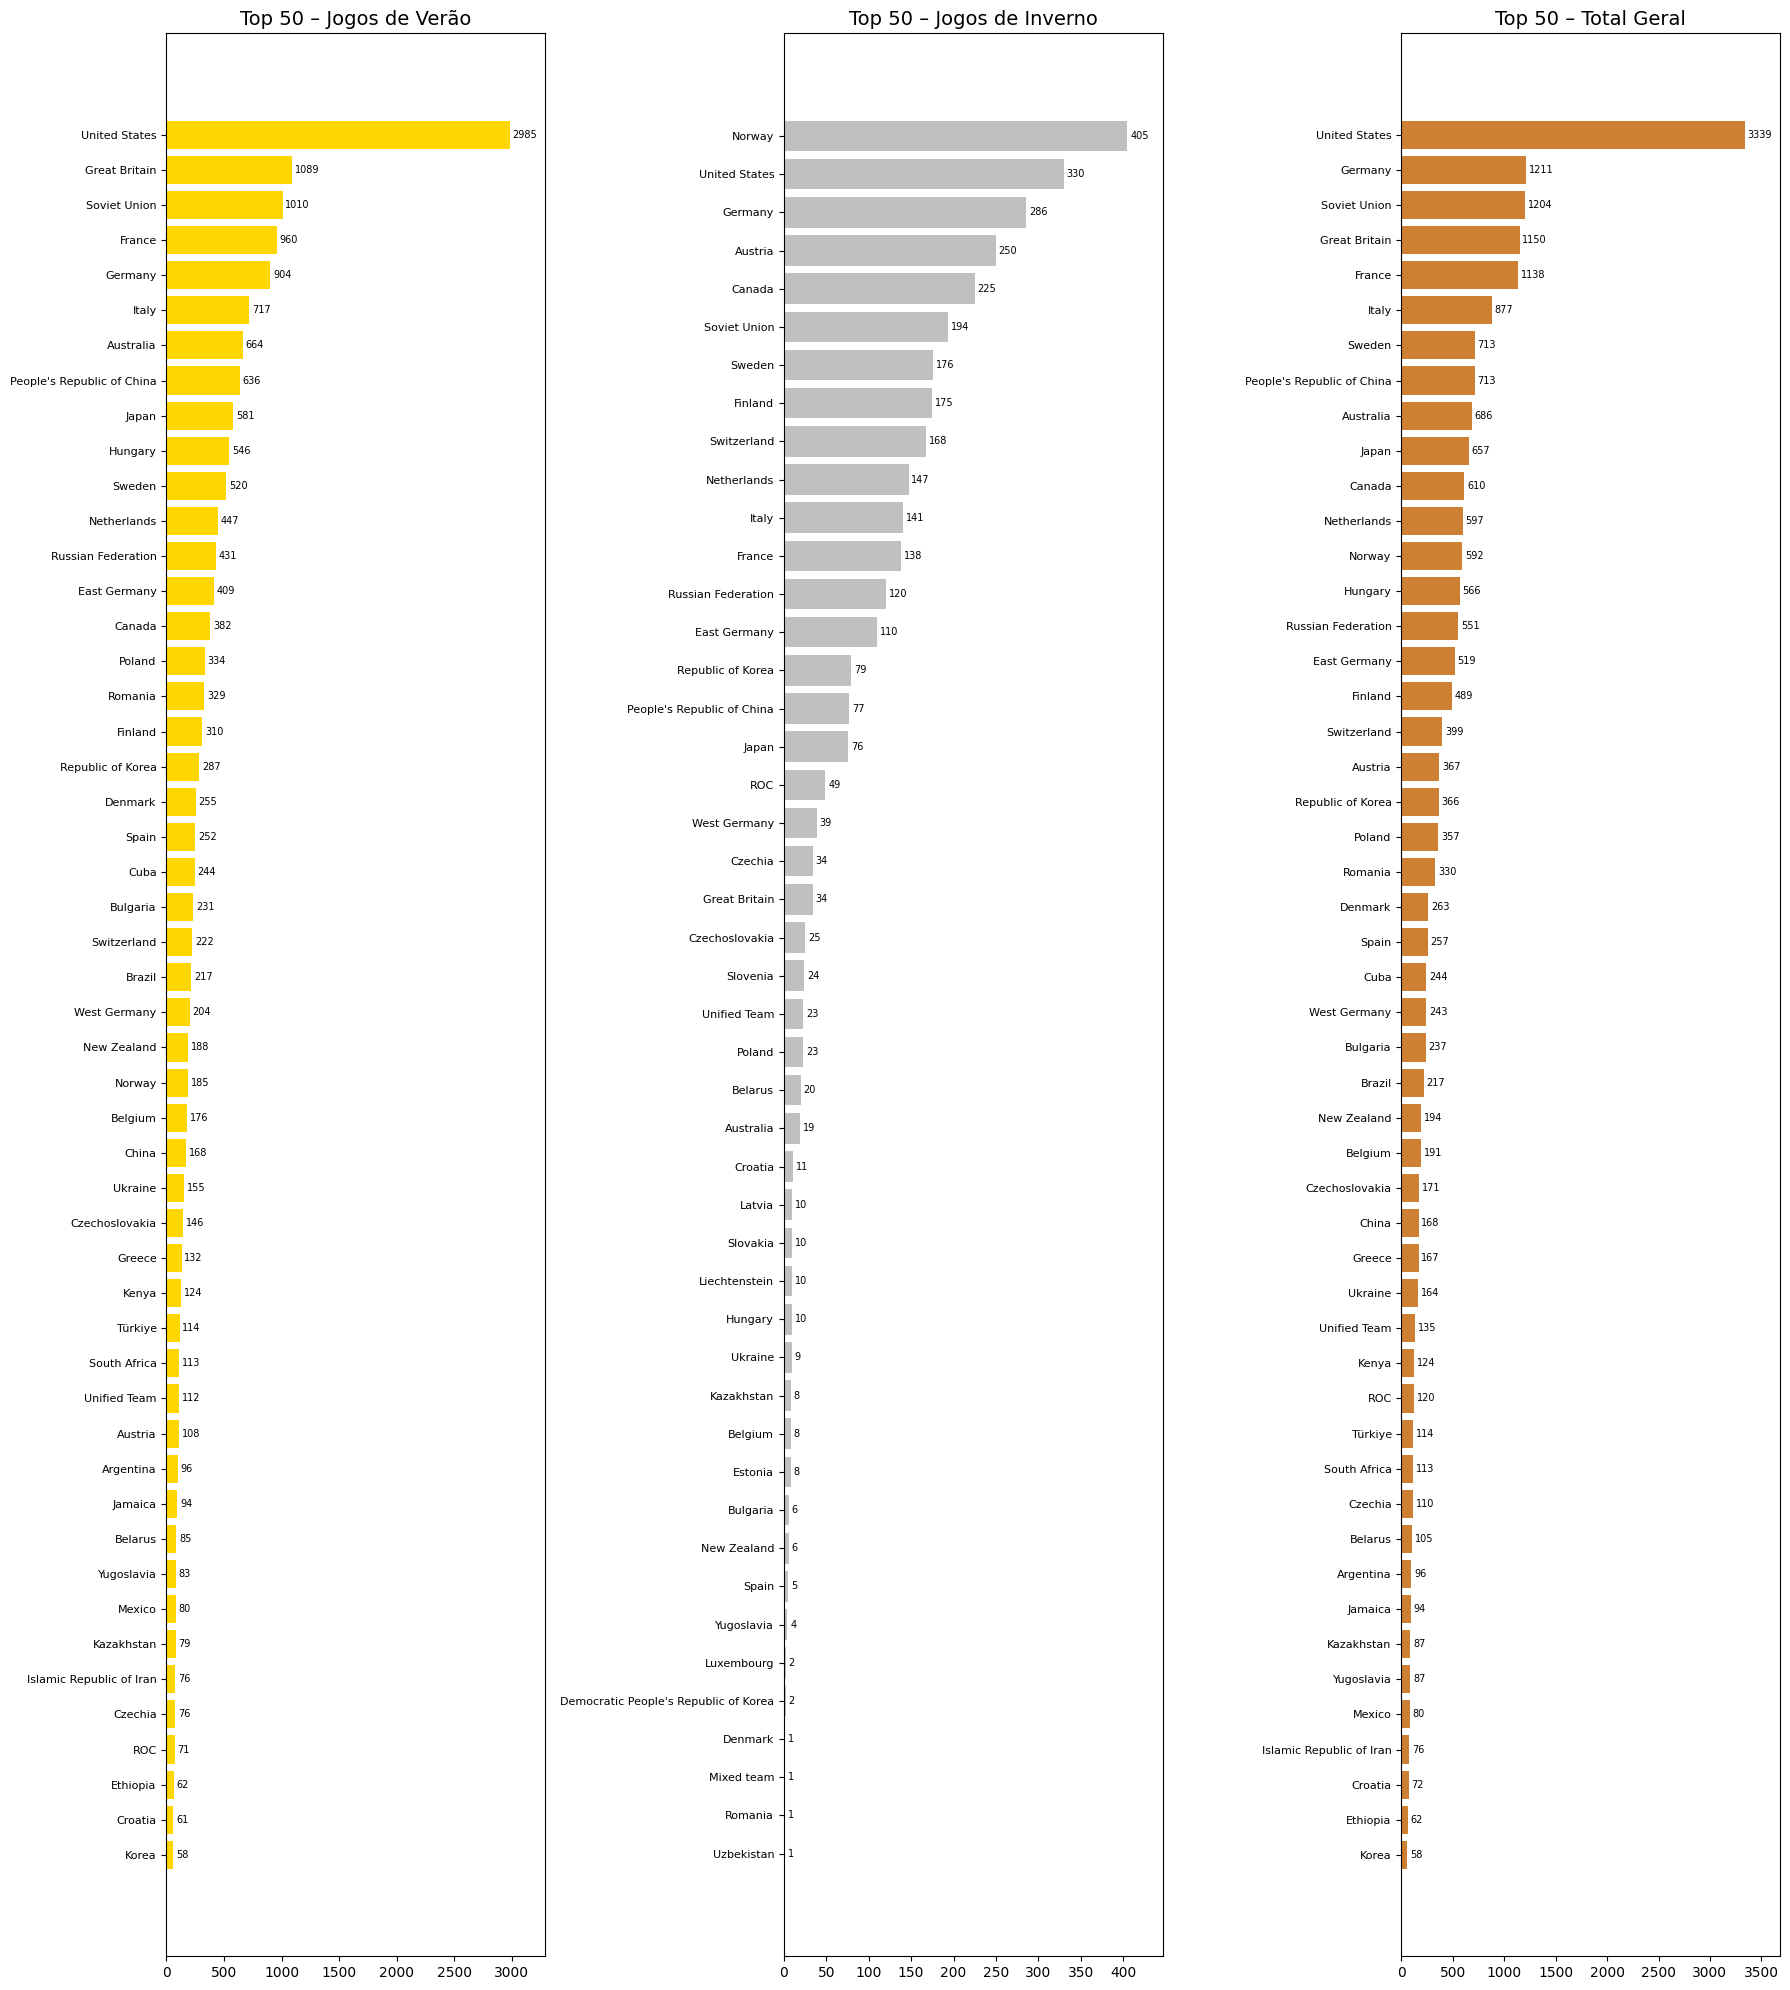

Gráfico principal salvo como medalhas_plot.png


In [18]:
top_n = 50
altura = 0.4 * top_n  # altura proporcional ao número de países

fig, axes = plt.subplots(1, 3, figsize=(18, altura))

# Verão
top_summer = summer_table.head(top_n)
bars_summer = axes[0].barh(top_summer['country_pt'], top_summer['total'], color='gold')
axes[0].set_title(f'Top {top_n} – Jogos de Verão', fontsize=14)
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)
# Adicionar rótulos com os valores
axes[0].bar_label(bars_summer, label_type='edge', padding=2, fontsize=7, fmt='%.0f')

# Inverno
top_winter = winter_table.head(top_n)
bars_winter = axes[1].barh(top_winter['country_pt'], top_winter['total'], color='silver')
axes[1].set_title(f'Top {top_n} – Jogos de Inverno', fontsize=14)
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)
axes[1].bar_label(bars_winter, label_type='edge', padding=2, fontsize=7, fmt='%.0f')

# Total
top_total = total_table.head(top_n)
bars_total = axes[2].barh(top_total['country_pt'], top_total['total'], color='#cd7f32')
axes[2].set_title(f'Top {top_n} – Total Geral', fontsize=14)
axes[2].invert_yaxis()
axes[2].tick_params(axis='y', labelsize=8)
axes[2].bar_label(bars_total, label_type='edge', padding=2, fontsize=7, fmt='%.0f')

# Ajustar limites para evitar que os rótulos saiam da figura
for ax in axes:
    ax.set_xlim(0, ax.get_xlim()[1] * 1.05)  # adiciona 5% de margem à direita

plt.tight_layout()
plt.savefig(GOLD_DIR / "medalhas_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico principal salvo como medalhas_plot.png")

### Gráficos adicionais

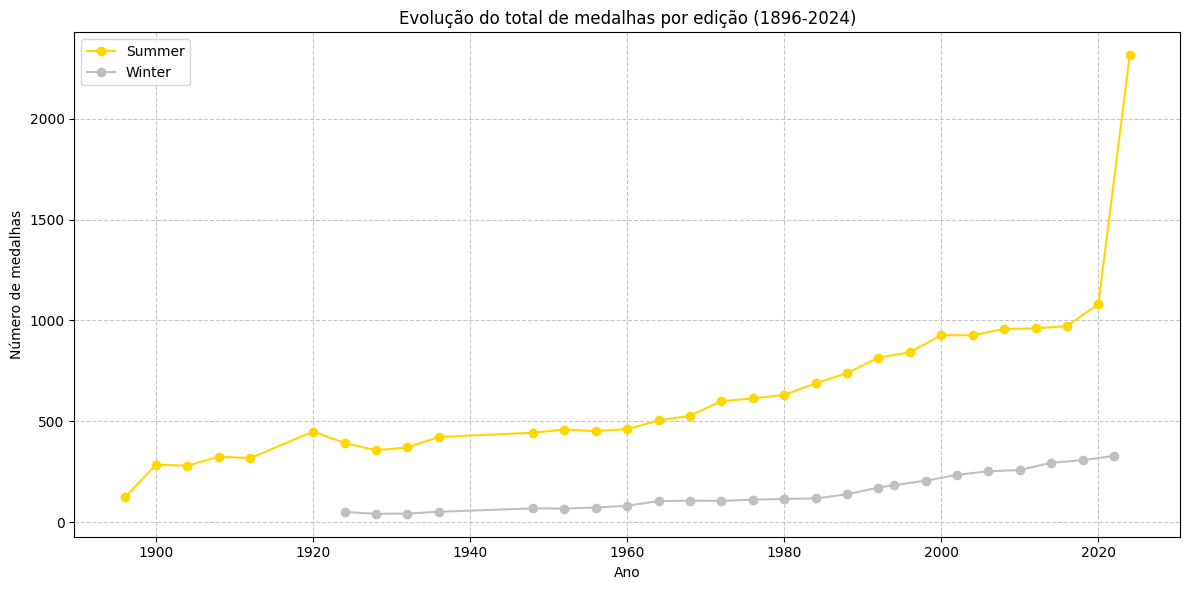

Gráfico de evolução salvo como evolucao_medalhas.png


In [19]:
# 1. Evolução do total de medalhas por ano (verão e inverno)
df_evol = df.groupby(['year', 'season'])[['gold', 'silver', 'bronze']].sum().reset_index()
df_evol['total'] = df_evol['gold'] + df_evol['silver'] + df_evol['bronze']

plt.figure(figsize=(12, 6))
for season, color in [('Summer', 'gold'), ('Winter', 'silver')]:
    data = df_evol[df_evol['season'] == season]
    plt.plot(data['year'], data['total'], marker='o', linestyle='-', color=color, label=season)
plt.title('Evolução do total de medalhas por edição (1896-2024)')
plt.xlabel('Ano')
plt.ylabel('Número de medalhas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(GOLD_DIR / "evolucao_medalhas.png", dpi=150)
plt.show()
print("Gráfico de evolução salvo como evolucao_medalhas.png")

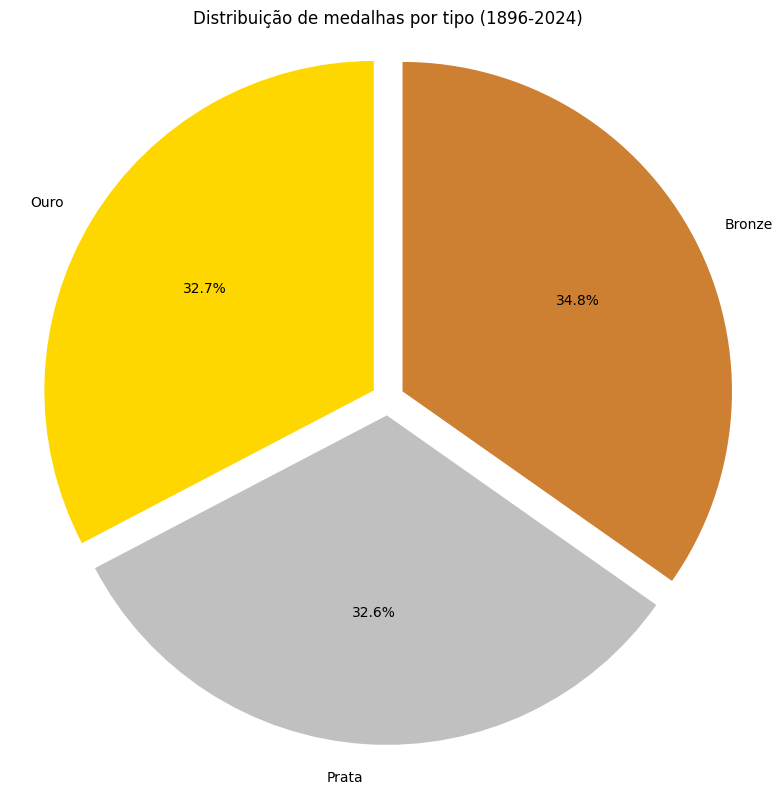

Gráfico de distribuição salvo como distribuicao_medalhas.png


In [20]:
# 2. Proporção de medalhas por tipo (total geral)
medal_totals = df[['gold', 'silver', 'bronze']].sum()
labels = ['Ouro', 'Prata', 'Bronze']
sizes = [medal_totals['gold'], medal_totals['silver'], medal_totals['bronze']]
colors = ['gold', 'silver', '#cd7f32']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição de medalhas por tipo (1896-2024)')
plt.axis('equal')
plt.tight_layout()
plt.savefig(GOLD_DIR / "distribuicao_medalhas.png", dpi=150)
plt.show()
print("Gráfico de distribuição salvo como distribuicao_medalhas.png")

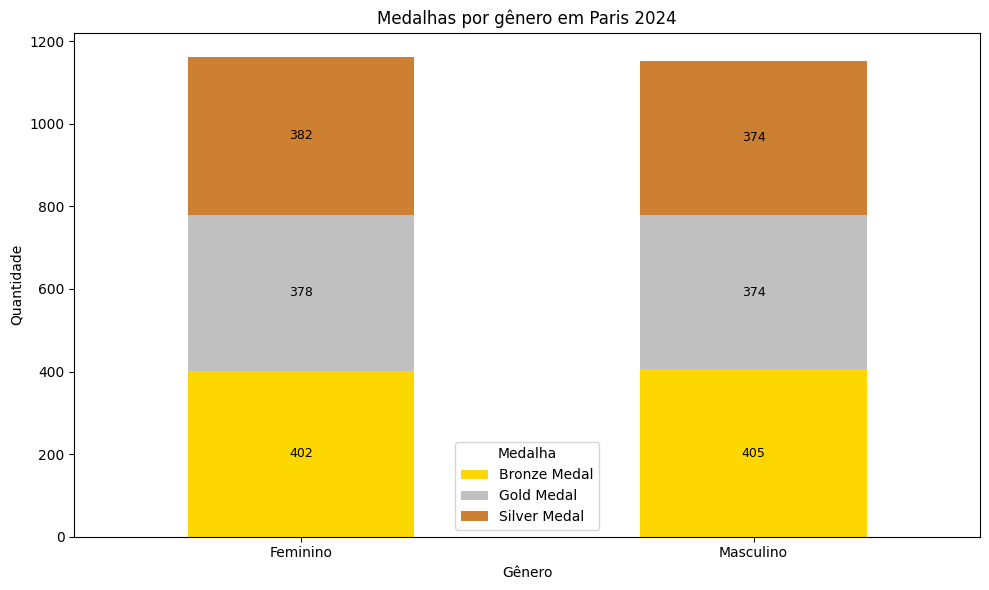

Gráfico de gênero salvo como medalhas_por_genero.png


In [21]:
# 3. Medalhas por gênero em Paris 2024
gender_medals = df_paris.groupby(['gender', 'medal_type']).size().unstack(fill_value=0)
# Renomear índices para português
gender_medals.index = gender_medals.index.map({'Male': 'Masculino', 'Female': 'Feminino'})

# Criar gráfico de barras empilhadas
ax = gender_medals.plot(kind='bar', stacked=True, figsize=(10, 6), color=['gold', 'silver', '#cd7f32'])
plt.title('Medalhas por gênero em Paris 2024')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(title='Medalha')
plt.xticks(rotation=0)

# Adicionar rótulos com os valores totais por barra (ou por segmento)
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9, fmt='%.0f')

plt.tight_layout()
plt.savefig(GOLD_DIR / "medalhas_por_genero.png", dpi=150)
plt.show()
print("Gráfico de gênero salvo como medalhas_por_genero.png")


### Metadados da análise

In [22]:
metadata_analise = {
    "nome_analise": "Quadro de Medalhas por País (Histórico + Paris 2024)",
    "descricao": "Ranking de países com ouro, prata, bronze e total, separado por verão, inverno e total geral, baseado nos dados unificados. Inclui tradução dos nomes dos países para português e gráficos adicionais (evolução, distribuição, gênero).",
    "arquivos_gerados": [
        "medalhas_verao.csv",
        "medalhas_inverno.csv",
        "medalhas_total.csv",
        "medalhas_plot.png",
        "evolucao_medalhas.png",
        "distribuicao_medalhas.png",
        "medalhas_por_genero.png"
    ],
    "notebook_associado": "notebooks/03_quadro_medalhas_gold.ipynb",
    "data_geracao": date.today().isoformat(),
    "observacoes": "Utiliza o dataset 'medalhas_unificado' da camada bronze. Gráficos mostram os 50 países mais medalhados com espaçamento ajustado para legibilidade. A evolução considera a soma de todas as medalhas por ano, independentemente do país."
}

with open(GOLD_DIR / "metadata.json", 'w', encoding='utf-8') as f:
    json.dump(metadata_analise, f, indent=2, ensure_ascii=False)

print("Metadados da análise salvos em metadata.json")
print("\n✅ Processamento concluído!")

Metadados da análise salvos em metadata.json

✅ Processamento concluído!
